# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

In [2]:
from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor

# Simulating data

## Single df

### Creating

In [3]:
gdf_output = return_spatial_geo_df3(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [4]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
127,1127,POINT (600 700),600,700,0,-3.032615,1,-0.652555,-1.170804,-0.276211,-2.193162,0.002726,0.407340,0.006693,400.0,0.006693,-2.643383,-2.538243
128,1128,POINT (600 800),600,800,0,-1.632874,1,-0.508811,-0.225228,0.120357,-1.416497,0.002525,0.377303,0.006693,400.0,0.006693,-1.600643,-1.450935
129,1129,POINT (600 900),600,900,0,1.788937,1,-0.366992,0.308780,0.250715,0.991251,0.005913,0.883531,0.006693,400.0,0.006693,0.785426,0.859642
130,1130,POINT (600 1000),600,1000,0,0.188505,1,0.851534,0.747704,-0.190766,-0.544578,0.008783,1.312240,0.006693,400.0,0.006693,0.426436,0.284891
131,1131,POINT (600 1100),600,1100,0,1.138758,1,-0.441085,-0.452318,1.569531,0.553248,0.003313,0.495030,0.006693,400.0,0.006693,0.929975,0.762903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1569,POINT (2800 900),2800,900,0,1.390689,1,1.057737,-0.367470,2.075617,-1.095096,0.007303,1.091173,0.006693,400.0,0.006693,0.585003,0.585003
570,1570,POINT (2800 1000),2800,1000,0,-0.003425,1,0.489853,1.337358,0.110757,-1.171965,0.009491,1.418100,0.006693,400.0,0.006693,0.082256,0.082256
571,1571,POINT (2800 1100),2800,1100,0,-0.639915,1,-0.415001,-1.606681,0.657987,0.274787,0.004295,0.641800,0.006693,400.0,0.006693,-0.622102,-0.622102
572,1572,POINT (2800 1200),2800,1200,0,0.093564,1,1.661487,-0.333414,-1.427749,-0.281284,0.009606,1.435283,0.006693,400.0,0.006693,0.522831,0.522831


In [5]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [6]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7241043326774512)

In [7]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5000000000000002)

In [8]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,1.286974,1,-0.281589,-0.219817,-1.055267,1.536674,1.422422,1.422422,1.0,0.0,1.0,1.563165,1.538455
208,1208,POINT (1000 800),1000,800,1,-3.110688,1,-0.311778,-1.261084,-1.191948,-0.987116,0.961146,0.961146,1.0,0.0,1.0,-1.158233,-1.497955
209,1209,POINT (1000 900),1000,900,1,3.317133,1,-0.237759,-0.113331,2.836843,2.054398,1.526793,1.526793,1.0,0.0,1.0,3.802396,3.706928
210,1210,POINT (1000 1000),1000,1000,1,-1.514519,1,-1.935971,0.381621,-0.495228,-0.246823,1.133352,1.133352,1.0,0.0,1.0,0.702652,0.444664
211,1211,POINT (1000 1100),1000,1100,1,-0.912704,1,-0.456328,-1.337506,1.075727,-0.632709,1.048643,1.048643,1.0,0.0,1.0,0.998348,0.693288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,1.479556,1,0.820576,-1.451789,0.516931,0.435873,1.707096,1.707096,1.0,0.0,1.0,2.823582,2.474523
490,1490,POINT (2400 1000),2400,1000,1,-0.761015,1,-1.146170,-0.513784,1.149738,0.321855,0.996541,0.996541,1.0,0.0,1.0,1.673480,1.302631
491,1491,POINT (2400 1100),2400,1100,1,1.395735,1,0.288843,-0.348647,0.579047,1.225876,1.726411,1.726411,1.0,0.0,1.0,3.221287,3.050903
492,1492,POINT (2400 1200),2400,1200,1,-1.706970,1,-0.822617,0.142302,-1.065427,-1.140239,1.023748,1.023748,1.0,0.0,1.0,-0.651364,-0.651364


In [9]:
gdf_output.isna().any().any()

np.False_

In [10]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.1797', 'p-value simulated: 0.0010']

#### Visual checks

In [11]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

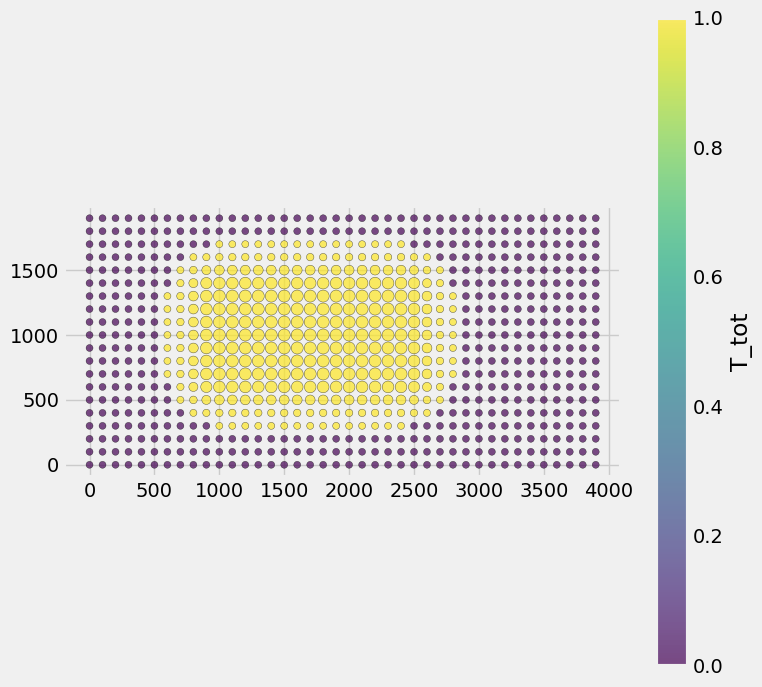

In [12]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

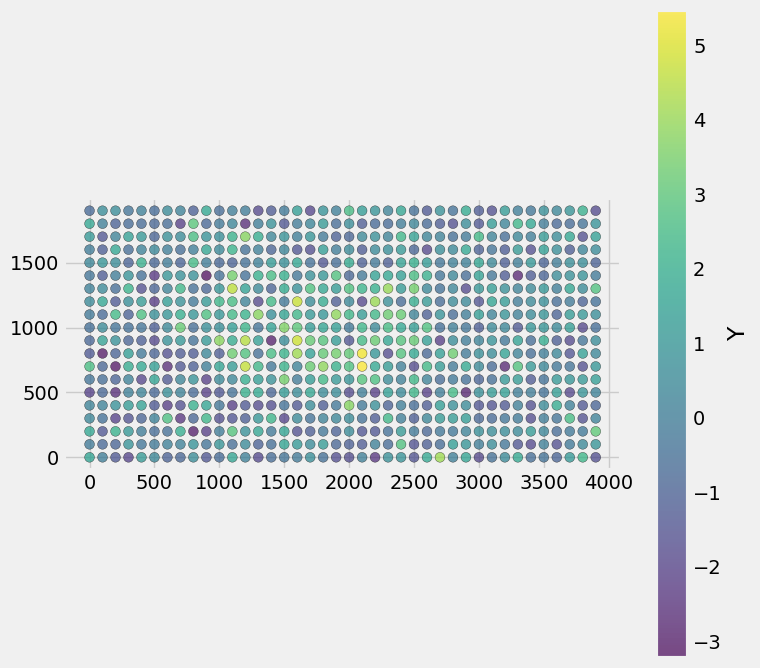

In [13]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

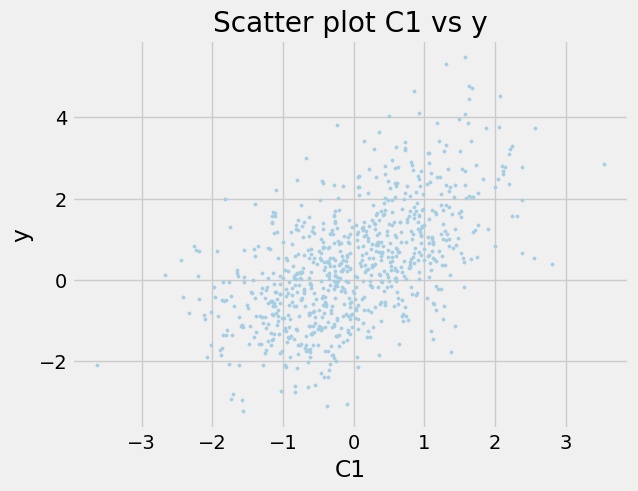

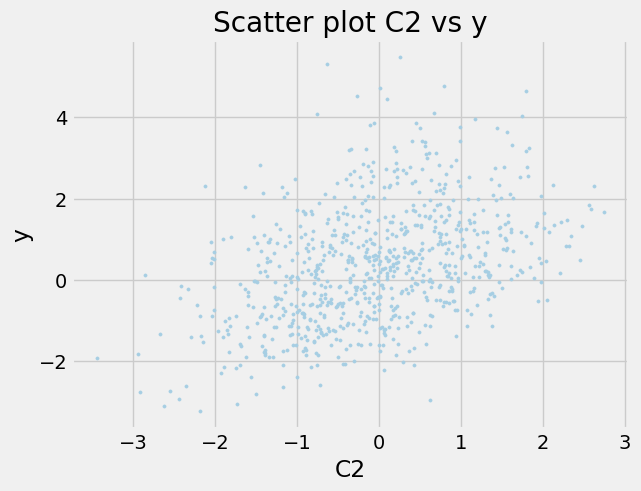

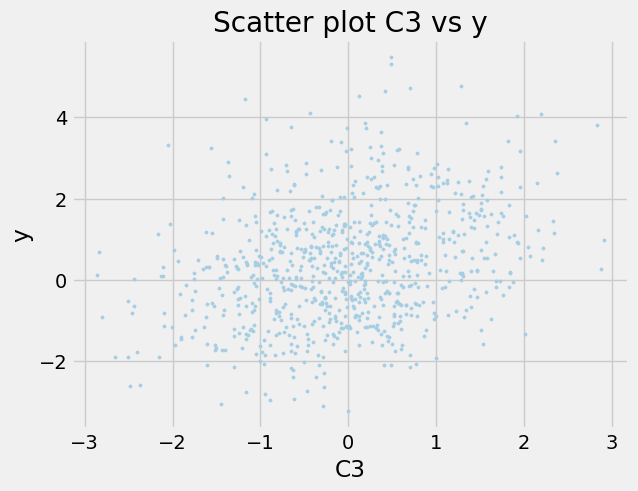

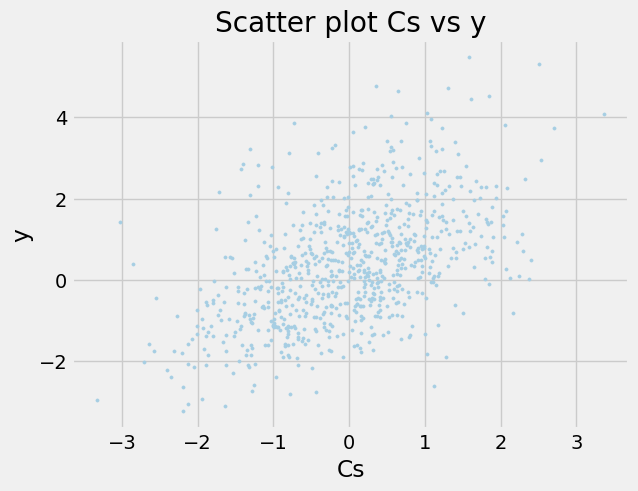

In [14]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [15]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [16]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.384672
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.01051
Time:                        21:03:18   Log-Likelihood:                -307.74
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                   0.03811
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9138      0.107    -17.869      0.000      -2.124      -1.704
x1             0.2637      0.

##### Cross sectional linear difference in differences 

In [17]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     373.5
Date:                Sun, 10 May 2026   Prob (F-statistic):          2.30e-151
Time:                        21:03:18   Log-Likelihood:                -1049.8
No. Observations:                 800   AIC:                             2108.
Df Residuals:                     796   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2124      0.034      6.202      0.0

In [18]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     313.4
Date:                Sun, 10 May 2026   Prob (F-statistic):          2.62e-134
Time:                        21:03:18   Log-Likelihood:                -1089.3
No. Observations:                 800   AIC:                             2187.
Df Residuals:                     796   BIC:                             2205.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1213      0.043      2.824      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [19]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.3713                Number of Variables   :           8
S.D. dependent var  :      1.4296                Degrees of Freedom    :         792
Pseudo R-squared    :      0.6144
Spatial Pseudo R-squared:  0.6110
Log likelihood      :  -1040.8061
Sigma-square ML     :      0.7871                Akaike info criterion :    2097.612
S.E of regression   :      0.8872                Schwarz criterion     :    2135.089

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [20]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.422422,1.858800
208,1208,POINT (1000 800),1,0.961146,0.998718
209,1209,POINT (1000 900),1,1.526793,1.959027
210,1210,POINT (1000 1000),1,1.133352,1.401632
211,1211,POINT (1000 1100),1,1.048643,1.173597
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.707096,1.750627
490,1490,POINT (2400 1000),1,0.996541,1.852229
491,1491,POINT (2400 1100),1,1.726411,1.435406
492,1492,POINT (2400 1200),1,1.023748,1.378783


In [21]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.4594465685250897),
 np.float64(1.4790229452321153),
 np.float64(1.498599321939141))

In [22]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.4980971512933707)

###### For T tot

In [23]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.002726,0.407340,0.333481
128,1128,POINT (600 800),1,0.002525,0.377303,1.081781
129,1129,POINT (600 900),1,0.005913,0.883531,1.025331
130,1130,POINT (600 1000),1,0.008783,1.312240,0.917500
131,1131,POINT (600 1100),1,0.003313,0.495030,1.206429
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.007303,1.091173,0.484451
570,1570,POINT (2800 1000),1,0.009491,1.418100,0.636115
571,1571,POINT (2800 1100),1,0.004295,0.641800,0.880679
572,1572,POINT (2800 1200),1,0.009606,1.435283,0.476708


#### S learner with multiple treatments

In [24]:
X

array([[ 2.30584791,  0.75454646],
       [-0.83746207, -0.70648807],
       [ 1.49121295, -0.91107578],
       ...,
       [ 0.57072242, -0.14190253],
       [ 1.99983224, -0.69173089],
       [-1.89039362, -1.12400857]], shape=(800, 2))

In [25]:
gdf_output4 = gdf_output.copy()

In [26]:
gdf_output4[gdf_output4['spill'] != 0]['spill'].value_counts()

spill
1.000000    105
0.006693     44
0.500000     44
0.075858     44
0.924142     44
0.017743      8
0.051873      8
0.356596      8
0.111941      4
0.812215      4
Name: count, dtype: int64

In [27]:
gdf_output4['treated'] = 'control'

In [28]:
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'


In [29]:
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

In [30]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [35]:
ate, lb, ub

(array([ 1.43678350e+00,  7.44493619e-01,  8.12074652e-02, -1.60465519e-02,
         8.92709513e-04]),
 array([ 1.32384782,  0.61200145, -0.02710338, -0.13843177, -0.14110257]),
 array([1.54971918, 0.87698579, 0.18951831, 0.10633867, 0.14288799]))

In [31]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [42]:
np.sqrt(len(ITE_df[ITE_df['treated']==i][i]))

np.float64(7.211102550927978)

In [45]:
att.std(ddof=1)

np.float64(nan)

In [48]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 [np.float64(-0.07165936837749545), np.float64(-0.00538509190890009), np.float64(0.060889184559695275)] 0.008738014342026776
outer_ring3 [np.float64(-0.08440597805421315), np.float64(-0.011823021711642859), np.float64(0.06075993463092744)] 0.07600716627326187
outer_ring2 [np.float64(0.03620292853444936), np.float64(0.08043839879025788), np.float64(0.1246738690460664)] 0.4428772043470615
outer_ring1 [np.float64(0.7599251867374754), np.float64(0.9153660643691627), np.float64(1.07080694200085)] 0.8655762790729669
inner_ring [np.float64(1.388204967332736), np.float64(1.5334973041293873), np.float64(1.6787896409260388)] 1.5000000000000002


In [33]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,outer_ring4,treated,ITE_real,Y
0,1.529334,0.951125,0.012821,0.612198,0.308515,control,0.0,1.565688
1,0.248790,1.074960,0.116664,-0.200062,0.199073,control,0.0,-0.122890
2,1.000748,0.107895,0.015261,0.098745,-0.022816,control,0.0,1.640509
3,1.084204,0.493801,-0.131973,-0.117239,-0.273877,control,0.0,0.342295
4,1.438816,0.746394,0.042962,0.040821,0.003586,control,0.0,0.209687
...,...,...,...,...,...,...,...,...
795,0.786185,0.521010,-0.005905,-0.223544,-0.161874,control,0.0,-0.976647
796,0.916106,0.480884,0.020608,-0.002473,-0.222908,control,0.0,0.529602
797,1.028385,1.493971,0.188350,-0.011638,0.244113,control,0.0,1.422797
798,1.878361,0.084952,-0.002719,0.199975,0.040768,control,0.0,0.839998


In [34]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5000000000000002)

## Generating multiple df for simulations

### Data generation

In [ ]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 
        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,
        ATT_target = 1.5,
        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,
        rho = i,
        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        lambda_cs = 0.2,
        distance_ring_number = 2,
        distance_ring_ate_scalars=[0.4, 0.15],
        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [ ]:
dict_of_output_gdf.keys()

In [ ]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

### Data saving

In [ ]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [ ]:
repo_path_r_string

In [ ]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )